### Plotting the Normalised Frequency for each length in query.bed

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict
import random

query_length_counts = defaultdict(int)
total_query_fragments = 0

# For getting query.bed file, use: python unzip_bed_files.py in the Programming-Assignment directory
with open("query.bed", "r") as query_file:
    for query_line in query_file:
        query_fields = query_line.strip().split()
        if len(query_fields) < 3:
            continue
        try:
            start_position = int(query_fields[1])
            end_position = int(query_fields[2])
            fragment_length = end_position - start_position
            if fragment_length > 0:
                query_length_counts[fragment_length] += 1
                total_query_fragments += 1
        except ValueError:
            continue

fragment_lengths = sorted(query_length_counts)
normalized_frequencies = [query_length_counts[length] / total_query_fragments for length in fragment_lengths]

print(f"Total fragments: {total_query_fragments}")

for fragment_length, frequency in zip(fragment_lengths, normalized_frequencies):
    print(f"Length: {fragment_length}, Frequency: {frequency:.4f}")

Total fragments: 9165460
Length: 24, Frequency: 0.0000
Length: 25, Frequency: 0.0002
Length: 26, Frequency: 0.0002
Length: 27, Frequency: 0.0002
Length: 28, Frequency: 0.0003
Length: 29, Frequency: 0.0004
Length: 30, Frequency: 0.0005
Length: 31, Frequency: 0.0005
Length: 32, Frequency: 0.0006
Length: 33, Frequency: 0.0007
Length: 34, Frequency: 0.0008
Length: 35, Frequency: 0.0114
Length: 36, Frequency: 0.0111
Length: 37, Frequency: 0.0110
Length: 38, Frequency: 0.0109
Length: 39, Frequency: 0.0111
Length: 40, Frequency: 0.0117
Length: 41, Frequency: 0.0122
Length: 42, Frequency: 0.0122
Length: 43, Frequency: 0.0115
Length: 44, Frequency: 0.0108
Length: 45, Frequency: 0.0107
Length: 46, Frequency: 0.0110
Length: 47, Frequency: 0.0113
Length: 48, Frequency: 0.0117
Length: 49, Frequency: 0.0120
Length: 50, Frequency: 0.0123
Length: 51, Frequency: 0.0126
Length: 52, Frequency: 0.0126
Length: 53, Frequency: 0.0124
Length: 54, Frequency: 0.0115
Length: 55, Frequency: 0.0107
Length: 56, Fre

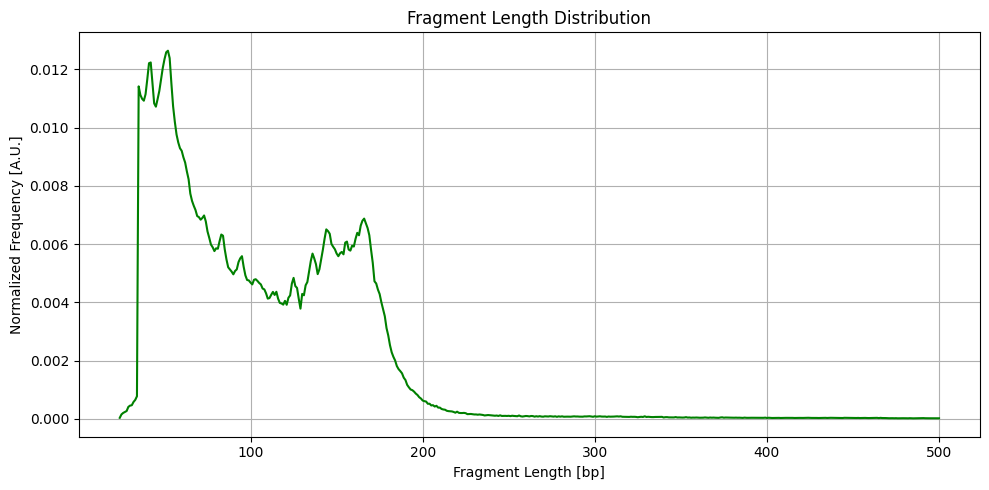

In [55]:
plt.figure(figsize=(10, 5))

plt.title("Fragment Length Distribution")

plt.plot(fragment_lengths, normalized_frequencies, color='green')

plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")

plt.grid(True)
plt.tight_layout()
plt.show()

### Rescaling of query along the reference

This section performs the following steps:
1. Load the reference fragment length distribution
2. Group query fragments by length
3. Resample fragments to match the reference distribution
4. Visualize the original and rescaled distributions

In [56]:
reference_distribution = {}

with open("reference.hist") as reference_file:
    for reference_line in reference_file:
        reference_parts = reference_line.strip().split()
        if len(reference_parts) < 2:
            continue
        ref_length = int(reference_parts[0])
        ref_frequency = float(reference_parts[1])
        reference_distribution[ref_length] = ref_frequency

total_reference_frequency = sum(reference_distribution.values())
normalized_reference = {length: freq / total_reference_frequency for length, freq in reference_distribution.items()}

In [57]:
length_to_fragments = defaultdict(list)

with open("query.bed", "r") as query_file:
    for query_line in query_file:
        query_fields = query_line.strip().split()
        if len(query_fields) < 3:
            continue
        try:
            start_position = int(query_fields[1])
            end_position = int(query_fields[2])
            fragment_length = end_position - start_position
            if fragment_length > 0:
                length_to_fragments[fragment_length].append(query_line.strip())
        except ValueError:
            continue

total_available_fragments = sum(len(fragments) for fragments in length_to_fragments.values())

In [58]:
resampled_fragments = []

for target_length, target_fraction in normalized_reference.items():
    if target_length in length_to_fragments:
        available_fragments = length_to_fragments[target_length]
        desired_count = int(round(target_fraction * total_available_fragments))
        selected_fragments = random.sample(available_fragments, min(desired_count, len(available_fragments)))
        resampled_fragments.extend(selected_fragments)

In [59]:
resampled_length_counts = defaultdict(int)
for fragment_entry in resampled_fragments:
    fragment_fields = fragment_entry.strip().split()
    fragment_length = int(fragment_fields[2]) - int(fragment_fields[1])
    resampled_length_counts[fragment_length] += 1

total_resampled_fragments = sum(resampled_length_counts.values())
resampled_lengths = sorted(resampled_length_counts.keys())
resampled_frequencies = [resampled_length_counts[length] / total_resampled_fragments for length in resampled_lengths]

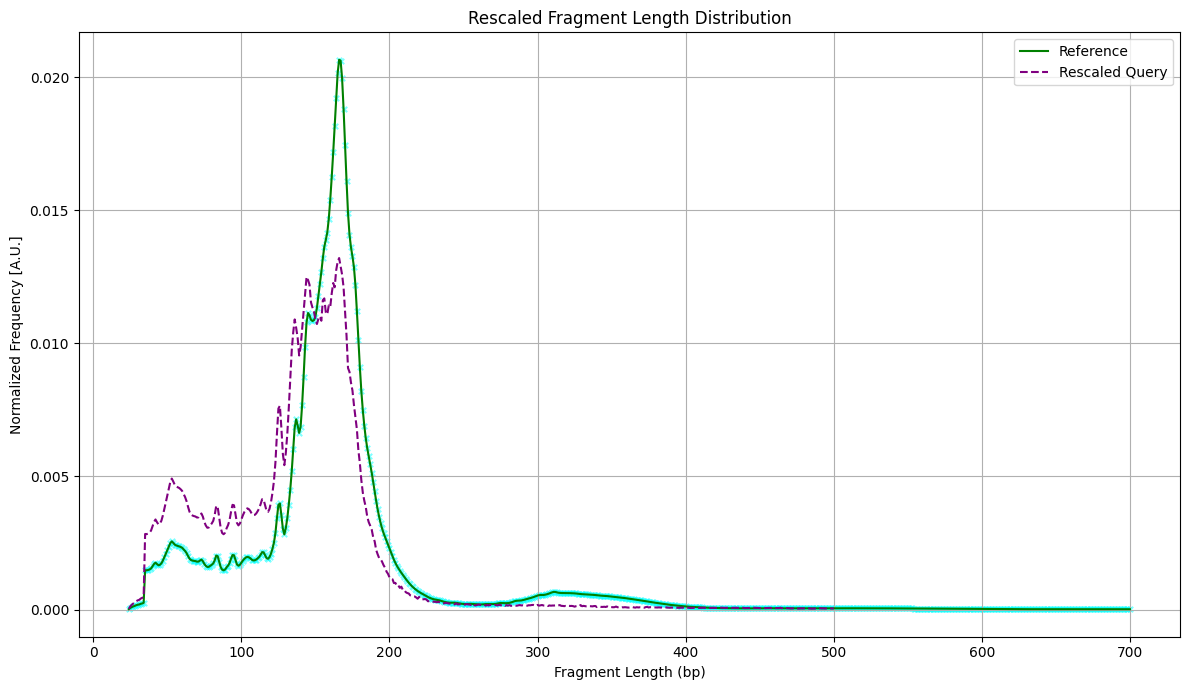

In [60]:
plt.figure(figsize=(12, 7))

reference_lengths = sorted(normalized_reference.keys())
reference_frequencies = [normalized_reference[length] for length in reference_lengths]

plt.title("Rescaled Fragment Length Distribution")

plt.plot(reference_lengths, reference_frequencies, label="Reference", color='green')
plt.scatter(reference_lengths, reference_frequencies, color='cyan', marker='x', s=15, alpha=0.5)


plt.plot(resampled_lengths, resampled_frequencies, label="Rescaled Query", color='purple', linestyle='dashed')

plt.legend()

plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")

plt.grid(True)
plt.tight_layout()
plt.show()